# Watch a trained model play, and read its training run

Loads a checkpoint (shared network by default), plays one game you can scrub through,
then plots the training run it came from: puzzle accuracy by depth, entropy, PPO dials,
game outcomes. For each position you see the board, the move played (SAN), the mover's
value output, the material balance from the mover's side, and **value + material**: under
potential-based shaping the value head learns `V - material`, so add material back before
reading whether the model thinks it is winning (see `learning/records/0003`).

In [4]:
# Reload src/ modules on every cell run, so edits to the code do not need a kernel restart.
%load_ext autoreload
%autoreload 2
import torch
from src.model.checkpoints import load_models
from src.viz.play import play_game

# Pick a checkpoint directory. Either layout loads:
#   shared network:  model_*.pth            (observations oriented to the mover)
#   legacy pair:     white_model_*.pth / black_model_*.pth
# Available locally:
#   experiments/potential-based-shaping/scale02/         scale 0.2, two networks
#   experiments/mate-in-one-curriculum/frac05-onemove/   curriculum run 2, two networks
#   experiments/shared-network/seed0/                    shared network, A2C
#   experiments/ppo-gae/C2_ppo_lr1e-4/                   PPO lr 1e-4, mate-in-one boards, 250 updates
#   experiments/mate-in-two-ply-cap/LONG/                PPO + mate-in-two + ply cap, 600 updates (continuation of BOTH)
CKPT_DIR = "experiments/mate-in-two-ply-cap/LONG"
# For a continued run, list the earlier segments first so the curves join up.
RUN_SEGMENTS = ["experiments/mate-in-two-ply-cap/BOTH", CKPT_DIR]
white_model, black_model, ORIENTED, paths = load_models(CKPT_DIR)
white_model.eval(); black_model.eval()
print("loaded:", paths, "| oriented:", ORIENTED)


white: experiments/potential-based-shaping/scale02/white_model_20260915161133_episodes_500.pth
black: experiments/potential-based-shaping/scale02/black_model_20260915161133_episodes_500.pth


In [ ]:
# SEED fixes the game so you can re-inspect it; change it (or use None) for a different game.
SEED = 0
# Greedy = always the most likely move (deterministic, ignores SEED). Sampled = draw
# from the policy. Mixing them shows how one side's best line fares against varied replies.
GREEDY_WHITE = True
GREEDY_BLACK = False
game = play_game(white_model, black_model, max_moves=300, seed=SEED, oriented=ORIENTED,
                 greedy_white=GREEDY_WHITE, greedy_black=GREEDY_BLACK)
print(f"{len(game.moves)} moves, result: {game.result}")

64 moves, result: draw


In [8]:
import html, json, uuid
import chess, chess.svg
from IPython.display import display, HTML

def render_replay(game, size=400):
    frames = []
    board = chess.Board()
    frames.append((chess.svg.board(board, size=size), "<b>Start position</b>"))
    for rec in game.moves:
        board = chess.Board(rec.fen_after)
        top = ", ".join(f"{s} {p:.2f}" for s, p in rec.top_moves)
        info = (f"<b>Move {rec.move_number}</b> {rec.side} plays <b>{html.escape(rec.san)}</b> "
                f"(p={rec.prob_played:.2f})<br>"
                f"value = {rec.value:+.2f} &nbsp; material = {rec.material:+.0f} &nbsp; "
                f"<b>value + material = {rec.value_plus_material:+.2f}</b><br>top-3: {html.escape(top)}")
        last = chess.Board(rec.fen_before).parse_san(rec.san)
        frames.append((chess.svg.board(board, size=size, lastmove=last), info))
    n = len(frames) - 1
    uid = uuid.uuid4().hex[:8]           # unique per render: reruns must not collide
    payload = json.dumps([[s, i] for s, i in frames])
    return f"""
<div id="rp_{uid}">
  <input type="range" min="0" max="{n}" value="0" style="width:600px">
  <span class="ply">ply 0 / {n}</span> &nbsp; result: <b>{game.result}</b> &nbsp; ({n} plies, render {uid})
  <div style="display:flex;gap:24px;align-items:flex-start;margin-top:8px">
    <div class="board"></div><div class="info" style="font-family:monospace"></div>
  </div>
</div>
<script>
(function () {{
  const root = document.getElementById("rp_{uid}");
  const frames = {payload};
  const show = (i) => {{
    root.querySelector(".board").innerHTML = frames[i][0];
    root.querySelector(".info").innerHTML = frames[i][1];
    root.querySelector(".ply").textContent = "ply " + i + " / {n}";
  }};
  root.querySelector("input").addEventListener("input", (e) => show(e.target.value));
  show(0);
}})();
</script>"""

display(HTML(render_replay(game)))

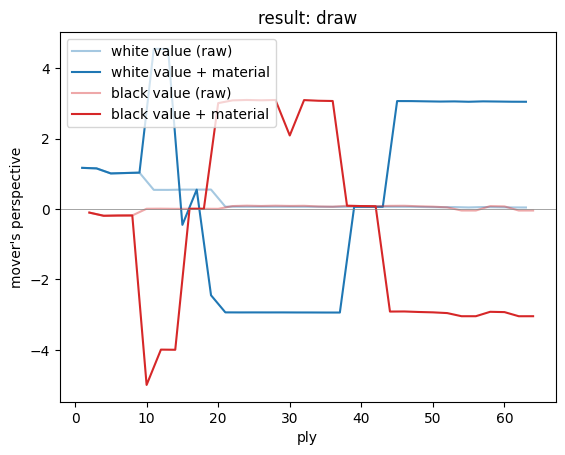

In [7]:
# Value vs value+material over the game, per side.
import matplotlib.pyplot as plt

for side, color in (("white", "tab:blue"), ("black", "tab:red")):
    recs = [m for m in game.moves if m.side == side]
    x = [m.move_number for m in recs]
    plt.plot(x, [m.value for m in recs], color=color, alpha=0.4, label=f"{side} value (raw)")
    plt.plot(x, [m.value_plus_material for m in recs], color=color, label=f"{side} value + material")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("ply"); plt.ylabel("mover's perspective"); plt.legend(); plt.title(f"result: {game.result}")
plt.show()

## The training run behind this checkpoint

`run.json` (written by `scripts/run_experiment.py`) holds the config and one log entry
per 10 updates; `games.json` (from `scripts/eval_games.py`) holds 40 uncapped evaluation
games. Reading order: puzzle panels first (is the curriculum being learned, and does
training solved rate agree with held-out accuracy?), then entropy (is the opening policy
alive?), then the PPO dials (how far did each update move the policy?), then games.

In [ ]:
import json
from pathlib import Path

def load_segments(dirs):
    logs, offset, cfg = [], 0, None
    for d in dirs:
        run = json.loads((Path(d) / "run.json").read_text())
        logs += [{**e, "episode": e["episode"] + offset} for e in run["logs"]]
        offset += run["config"]["max_updates"]; cfg = run["config"]
    return logs, cfg

def series(logs, key):
    return ([e["episode"] for e in logs if e.get(key) is not None],
            [e[key] for e in logs if e.get(key) is not None])

LOGS, CFG = load_segments([d for d in RUN_SEGMENTS if (Path(d) / "run.json").exists()])
print(f"{len(LOGS)} log entries, {LOGS[-1]['episode']} updates x {CFG['steps_per_update']} plies, "
      f"algorithm {CFG.get('algorithm', 'a2c')}, lr {CFG['learning_rate']}, max_plies {CFG.get('max_plies')}")

PANELS = [
    (["puzzle_solved_rate_m1", "puzzle_solved_rate_m2", "puzzle_solved_rate"], "training puzzle boards: solved rate"),
    (["lichess_top1", "lichess_m2_top1", "selfplay_top1"], "held-out top-1 (every eval_interval)"),
    (["mean_entropy_normalized_game", "mean_entropy_normalized_puzzle"], "normalised entropy: opening vs puzzle boards"),
    (["mean_clip_fraction", "mean_approx_kl"], "PPO dials"),
    (["mean_value_loss", "mean_policy_loss"], "losses"),
    (["draw_rate", "white_win_rate", "black_win_rate"], "game boards: outcome rates per window"),
]
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (keys, title) in zip(axes.flat, PANELS):
    for k in keys:
        xs, ys = series(LOGS, k)
        if xs:
            ax.plot(xs, ys, marker="o" if "top1" in k else None, ms=3, label=k)
    ax.set_title(title); ax.set_xlabel("update"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Games finished per window tell whether the ply cap is doing its job (more, shorter games).
xs, ys = series(LOGS, "total_games")
plt.figure(figsize=(8, 3)); plt.plot(xs, ys); plt.title("games finished per log window (game boards)"); plt.xlabel("update"); plt.show()

games_path = Path(CKPT_DIR) / "games.json"
if games_path.exists():
    g = json.loads(games_path.read_text())
    print({k: g[k] for k in ["games", "draw_rate", "decisive_rate", "mean_plies",
                              "mate_in_one_opportunities", "mate_in_one_found", "mate_in_one_rate"]})
    print("evaluation games are uncapped: a low mean_plies here is the policy's doing, not max_plies")
else:
    print("no games.json yet: python -m scripts.eval_games", CKPT_DIR)